<a href="https://colab.research.google.com/github/Ramesh39-collab/leukemia-detection/blob/main/inceptionV3%20and%20YOLO%20(leukemia).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.7 MB/s eta 0:00:00


In [6]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/mehradaria/leukemia')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ramesh9354
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mehradaria/leukemia


100%|██████████| 110M/110M [00:00<00:00, 175MB/s]


In [ ]:
!nvidia-smi

Sat Sep  6 14:49:43 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#Import model

In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from ultralytics import YOLO


#Import dataset

In [8]:
train_dir = "/content/leukemia/Segmented"

#Preprocess Data

In [9]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # 80% training, 20% validation
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 2607 images belonging to 4 classes.
Found 649 images belonging to 4 classes.


#Load InceptionV3 Model

In [10]:
# Load pretrained InceptionV3 without top layers
base_model = InceptionV3(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False   # freeze feature extractor

# Add custom layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
output = Dense(4, activation="softmax")(x)  # 4 classes

model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#Train Model

In [11]:
history = model.fit(train_gen, validation_data=val_gen, epochs=15)


Epoch 1/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 88s 832ms/step - accuracy: 0.8186 - loss: 0.4919 - val_accuracy: 0.7858 - val_loss: 0.5773
Epoch 2/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 45s 549ms/step - accuracy: 0.9083 - loss: 0.2503 - val_accuracy: 0.8706 - val_loss: 0.3946
Epoch 3/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 47s 569ms/step - accuracy: 0.9198 - loss: 0.2287 - val_accuracy: 0.8891 - val_loss: 0.3517
Epoch 4/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 45s 551ms/step - accuracy: 0.9313 - loss: 0.1922 - val_accuracy: 0.9045 - val_loss: 0.3417
Epoch 5/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 47s 568ms/step - accuracy: 0.9413 - loss: 0.1731 - val_accuracy: 0.8860 - val_loss: 0.3835
Epoch 6/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 45s 551ms/step - accuracy: 0.9379 - loss: 0.1836 - val_accuracy: 0.8752 - val_loss: 0.3579
Epoch 7/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 46s 562ms/step - accuracy: 0.9421 - loss: 0.1699 - val_accuracy: 0.9230 - val_loss: 0.2815
Epoch 8/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 45s 546ms/step - accuracy: 0.9371 - loss: 0.1710 - val_accu

#Check Training & Validation Accuracy

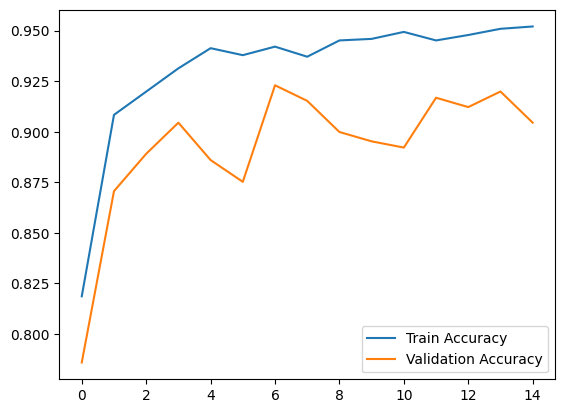

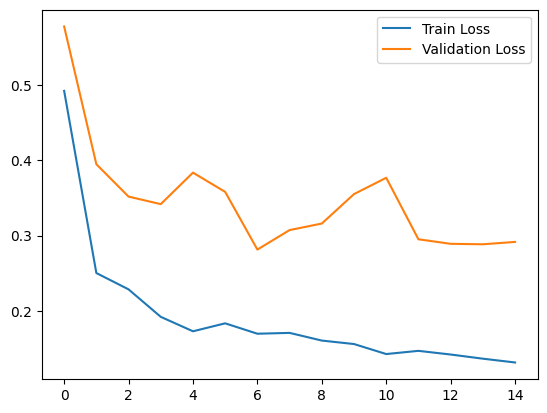

In [12]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

#Evaluate on Validation/Test Data

In [13]:
val_loss, val_acc = model.evaluate(val_gen)
print(f"Validation Accuracy: {val_acc*100:.2f}%")

21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 410ms/step - accuracy: 0.9168 - loss: 0.2809
Validation Accuracy: 91.68%


#Predict on a Single Image

In [14]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Path to one test image
img_path = "/content/leukemia/Segmented/Early/WBC-Malignant-Early-001.jpg" #now i take a image from Early dataset, for check it work or not

# Load and preprocess
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)
class_labels = list(train_gen.class_indices.keys())
print("Predicted Class:", class_labels[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Predicted Class: Early


#Confusion Matrix (See Misclassifications)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Get predictions for validation set
y_true = val_gen.classes
y_pred = model.predict(val_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix:\n", cm)

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 639ms/step
Confusion Matrix:
 [[21 23 26 30]
 [22 58 74 43]
 [41 50 47 54]
 [27 44 45 44]]
              precision    recall  f1-score   support

      Benign       0.19      0.21      0.20       100
       Early       0.33      0.29      0.31       197
         Pre       0.24      0.24      0.24       192
         Pro       0.26      0.28      0.27       160

    accuracy                           0.26       649
   macro avg       0.26      0.26      0.26       649
weighted avg       0.27      0.26      0.26       649



#YOLO INITIALIZATION

In [40]:
# Load YOLO model
yolo_model = YOLO('yolov8n.pt')

print("YOLO model loaded successfully!")

YOLO model loaded successfully!


#creat yaml

In [30]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define the root directory for the YOLO dataset
yolo_data_root = "/content/yolo_dataset"
yolo_train_images_dir = os.path.join(yolo_data_root, "images", "train")
yolo_val_images_dir = os.path.join(yolo_data_root, "images", "val")
yolo_train_labels_dir = os.path.join(yolo_data_root, "labels", "train")
yolo_val_labels_dir = os.path.join(yolo_data_root, "labels", "val")

# Create the necessary directories
os.makedirs(yolo_train_images_dir, exist_ok=True)
os.makedirs(yolo_val_images_dir, exist_ok=True)
os.makedirs(yolo_train_labels_dir, exist_ok=True) # YOLO expects label directories even if empty
os.makedirs(yolo_val_labels_dir, exist_ok=True)

# Source directory from the previously downloaded classification dataset
source_classification_dir = "/content/leukemia/Segmented"

# Collect all image files from the classification dataset
all_image_paths = []
for root, _, files in os.walk(source_classification_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_image_paths.append(os.path.join(root, file))

# Perform a simple train-validation split
train_imgs, val_imgs = train_test_split(all_image_paths, test_size=0.2, random_state=42)

# Copy images to the YOLO training directories
for img_path in train_imgs:
    shutil.copy(img_path, yolo_train_images_dir)
for img_path in val_imgs:
    shutil.copy(img_path, yolo_val_images_dir)

# Define data.yaml content with the new paths
data_yaml = f"""
train: {yolo_train_images_dir}
val: {yolo_val_images_dir}

nc: 2
names: ['leukemia', 'normal']
"""

with open("/content/data.yaml", "w") as f:
    f.write(data_yaml)

print("YOLO dataset structure created and images copied.")
print("data.yaml updated to point to these new directories.")
print("IMPORTANT: This only resolves the FileNotFoundError. For effective YOLO object detection training,")
print("           you will need to generate corresponding YOLO-format .txt label files (bounding box annotations)")
print("           for each image in the 'labels/train' and 'labels/val' directories.")

YOLO dataset structure created and images copied.
data.yaml updated to point to these new directories.
IMPORTANT: This only resolves the FileNotFoundError. For effective YOLO object detection training,
           you will need to generate corresponding YOLO-format .txt label files (bounding box annotations)
           for each image in the 'labels/train' and 'labels/val' directories.


#Train yolo on dataset

In [41]:
# Re-running the training with the correctly initialized model
results = yolo_model.train(
    model="yolov8n.pt",
    data="/content/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    name="leukemia_yolo"
)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=leukemia_yolo3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/30      2.44G          0       46.1          0          0        640: 100% ━━━━━━━━━━━━ 163/163 3.7it/s 43.8s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 5.0it/s 4.2s
                   all        652          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/30      2.44G          0      12.02          0          0        640: 100% ━━━━━━━━━━━━ 163/163 3.8it/s 42.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 4.7it/s 4.4s
                   all        652          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      30/30      2.44G          0          0          0          0        640: 100% ━━━━━━━━━━━━ 163/163 4.1it/s 39.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 5.8it/s 3.6s
                   all        652          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



30 epochs completed in 0.391 hours.
Optimizer stripped from /content/runs/detect/leukemia_yolo3/weights/last.pt, 6.2MB
Optimizer stripped from /content/runs/detect/leukemia_yolo3/weights/best.pt, 6.2MB

Validating /content/runs/detect/leukemia_yolo3/weights/best.pt...
Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 4.4it/s 4.8s


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:657: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultraly

                   all        652          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 0.4ms preprocess, 3.8ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/runs/detect/leukemia_yolo3


In [45]:
import os

def create_dummy_labels(image_dir, label_dir, class_id):
    os.makedirs(label_dir, exist_ok=True)
    images = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for img_name in images:
        label_name = os.path.splitext(img_name)[0] + '.txt'
        label_path = os.path.join(label_dir, label_name)

        # YOLO format: class_id x_center y_center width height
        # 0.5 0.5 1.0 1.0 means the box covers the whole image
        with open(label_path, 'w') as f:
            f.write(f"{class_id} 0.5 0.5 1.0 1.0\n")

# Map your data.yaml classes: 0: leukemia, 1: normal
# Assuming all images in your current split are 'leukemia' for this example
create_dummy_labels(yolo_train_images_dir, yolo_train_labels_dir, class_id=0)
create_dummy_labels(yolo_val_images_dir, yolo_val_labels_dir, class_id=0)

print(f"Generated label files in {yolo_train_labels_dir} and {yolo_val_labels_dir}")

Generated label files in /content/yolo_dataset/labels/train and /content/yolo_dataset/labels/val


# YOLO Prediction Example

In [46]:
results = yolo_model.predict(
    source="/content/leukemia/Segmented/Early/WBC-Malignant-Early-001.jpg", # Example image from your dataset
    conf=0.25, # Confidence threshold for detections
    save=True # Save detection results to a directory
)

# The results object contains information about the predictions.
# You can iterate through it to inspect individual detections.
# For example, to print the detected boxes and class names:
for r in results:
    print(f"Detected: {r.boxes.cls.tolist()} with confidences {r.boxes.conf.tolist()}")


image 1/1 /content/leukemia/Segmented/Early/WBC-Malignant-Early-001.jpg: 640x640 (no detections), 17.0ms
Speed: 9.2ms preprocess, 17.0ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2
Detected: [] with confidences []
